<a href="https://colab.research.google.com/github/AbrilCG/Fase-II/blob/main/Fase_II.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Fase 2

Nombre Proyecto: Modelo de Participacion en los Juegos Olimpicos

Cliente: Juegos Olimpicos

1. Revisa:
Los conceptos generales de los lenguajes de programación y sus enfoques hacia a la inteligencia artificial.
El funcionamiento de los diccionarios y conjuntos en Python.
La forma de declarar funciones y combinarlas con las estructuras de control en Python.
La instalación y uso de las librerías NumPy, Pandas y Matplotlib en Python.
2. Agrupa los datos recopilados en un fichero tipo texto que pueda ser importado a Python, de preferencia “csv” (Comma Separated Values) o “xlsx” (Microsoft Excel Spreadsheet as Data Charts).
3. Prepara tu entorno de trabajo en Jupyter Notebook dentro de la plataforma IBM Cloud, puedes apoyarte en la guía compartida en el anexo 1.
Importa el fichero de datos al entorno de trabajo y realiza las siguientes operaciones:
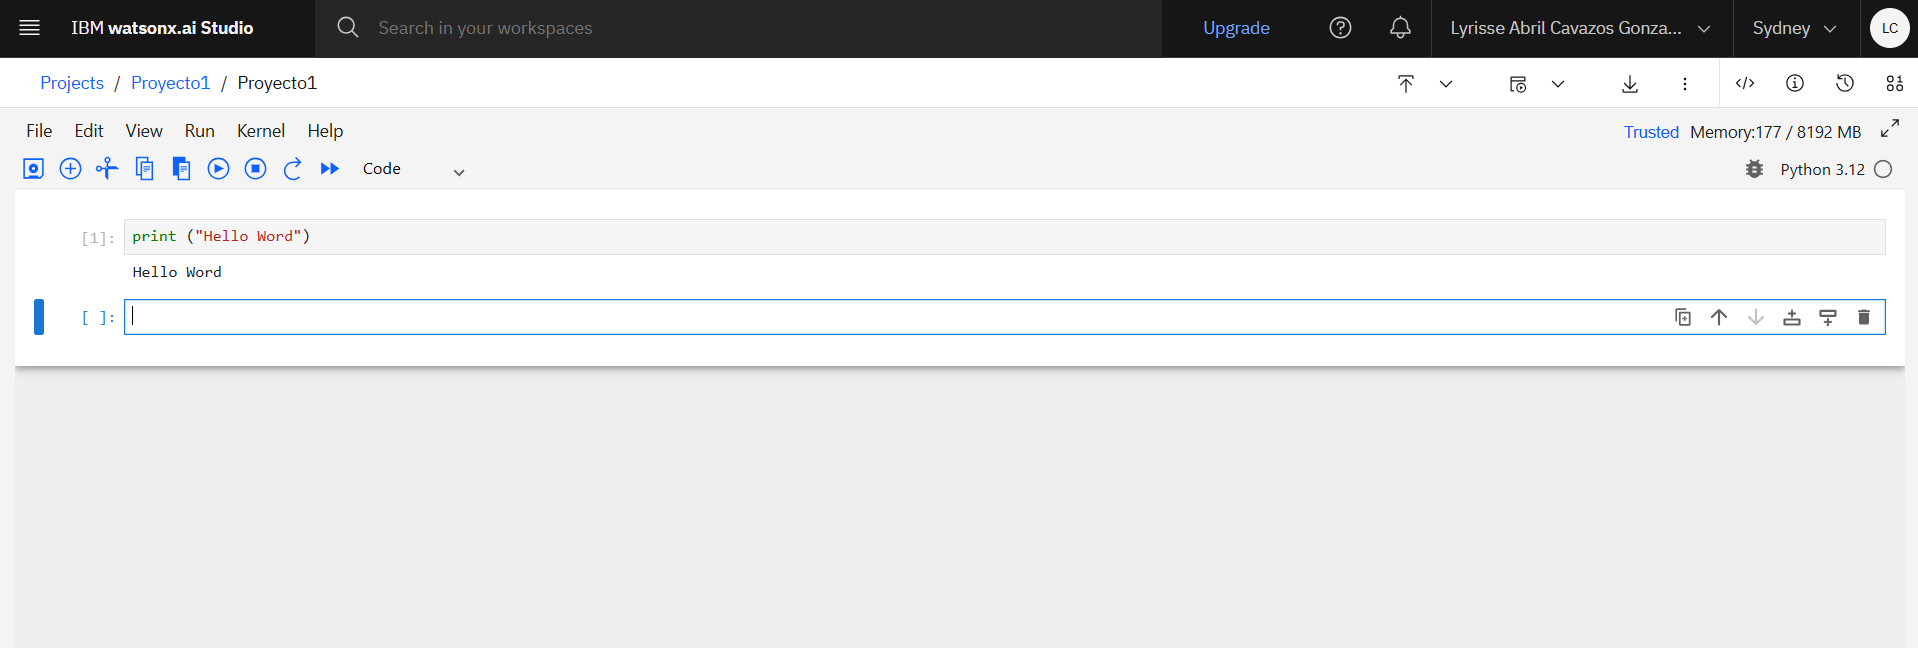
4. Importa las librerías NumPy, Pandas y Matplotlib a tu notebook.
Genera un Dataframe con los datos incluidos en el fichero de datos obtenido en el punto 2.
Organiza la información dentro de Dataframe de la forma que mejor se adecue a la problemática que se desea analizar, modifica el tipo de variable en caso de ser necesario.
Aplica una función matemática que te permita sintetizar parte de los datos dentro del Dataframe.
Selecciona una muestra de los datos y representa gráficamente la información que aportan.
5. Elabora un resumen de la información relevante obtenida, presenta tus conclusiones en un documento electrónico y compártela con tus compañeros en el foro indicado por el profesor (puede ser un material audiovisual en caso de ser requerido).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
# Cargar el dataset (Data Frame)

df = pd.read_csv('athlete_events.csv', skiprows=4)
df = df.dropna(axis=1, how='all')
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 271112 entries, 0 to 271111
Data columns (total 15 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   4                            271112 non-null  int64  
 1   Edgar Lindenau Aabye         271112 non-null  object 
 2   M                            271112 non-null  object 
 3   34                           261638 non-null  float64
 4   NA                           210943 non-null  float64
 5   NA.1                         208239 non-null  float64
 6   Denmark/Sweden               271112 non-null  object 
 7   DEN                          271112 non-null  object 
 8   1900 Summer                  271112 non-null  object 
 9   1900                         271112 non-null  int64  
 10  Summer                       271112 non-null  object 
 11  Paris                        271112 non-null  object 
 12  Tug-Of-War                   271112 non-null  object 
 13 

In [6]:
pd.set_option('display.max_columns', None)

In [22]:
data = pd.read_csv(PATH)
data.head()

,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,Year,Season,City,Sport,Event,Medal
0,1,A Dijiang,M,24.0,180.0,80.0,China,CHN,1992 Summer,1992,Summer,Barcelona,Basketball,Basketball Men's Basketball,NaN
1,2,A Lamusi,M,23.0,170.0,60.0,China,CHN,2012 Summer,2012,Summer,London,Judo,Judo Men's Extra-Lightweight,NaN
2,3,Gunnar Nielsen Aaby,M,24.0,NaN,NaN,Denmark,DEN,1920 Summer,1920,Summer,Antwerpen,Football,Football Men's Football,NaN
3,4,Edgar Lindenau Aabye,M,34.0,NaN,NaN,Denmark/Sweden,DEN,1900 Summer,1900,Summer,Paris,Tug-Of-War,Tug-Of-War Men's Tug-Of-War,Gold
4,5,Christine Jacoba Aaftink,F,21.0,185.0,82.0,Netherlands,NED,1988 Winter,1988,Winter,Calgary,Speed Skating,Speed Skating Women's 500 metres,NaN


In [13]:
data.columns

Index(['ID', 'Name', 'Sex', 'Age', 'Height', 'Weight', 'Team', 'NOC', 'Games',
       'Year', 'Season', 'City', 'Sport', 'Event', 'Medal'],
      dtype='object')

In [23]:
print(f"El número de filas es: {data.shape[0]}, el número de columnas es {data.shape[1]}.")

El número de filas es: 271116, el número de columnas es 15.


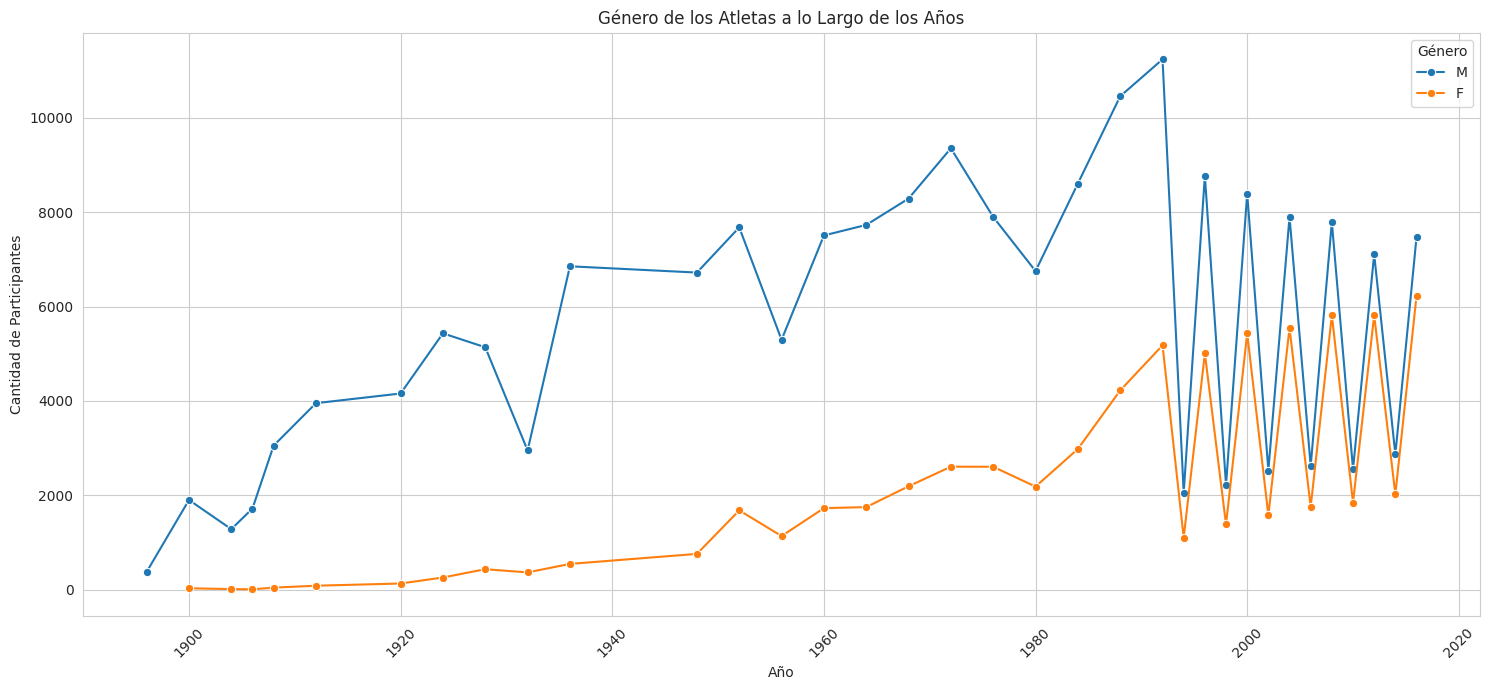

In [80]:
# Calcular el numero de participantes por genero por año
gender_distribution_over_time = data.groupby(['Year', 'Sex']).size().reset_index(name='Cantidad de Participantes')

plt.figure(figsize=(15, 7))
sns.set_style("whitegrid")
sns.lineplot(data=gender_distribution_over_time, x='Year', y='Cantidad de Participantes', hue='Sex', marker='o')
plt.title('Género de los Atletas a lo Largo de los Años')
plt.xlabel('Año')
plt.ylabel('Cantidad de Participantes')
plt.xticks(rotation=45)
plt.legend(title='Género')
plt.tight_layout()
plt.show()

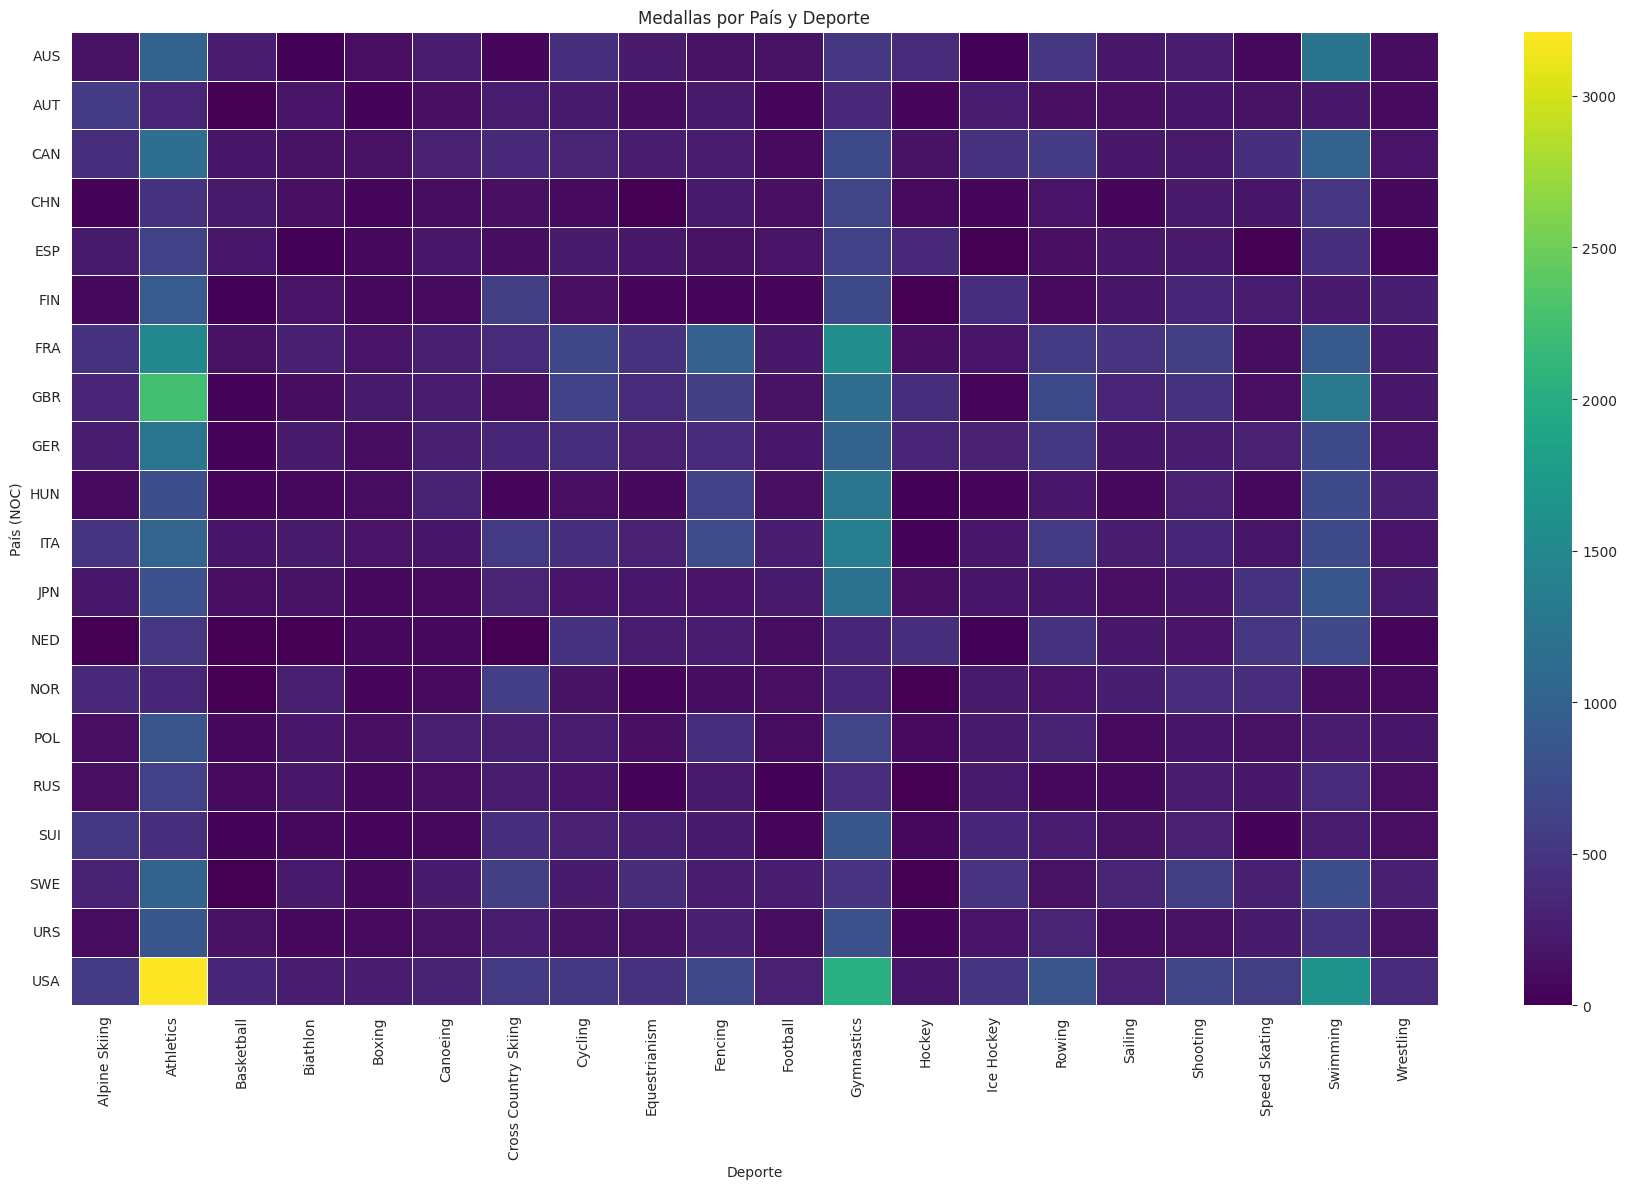

In [81]:
# Cantidad de medallas por pais y deportes
medals_only = data[data['Medal'] != 'No Medal']

medals_per_country_sport = medals_only.groupby(['NOC', 'Sport']).size().reset_index(name='Cantidad de Medallas')

top_countries = medals_per_country_sport.groupby('NOC')['Cantidad de Medallas'].sum().nlargest(20).index # Adjust N as needed

top_sports = medals_per_country_sport.groupby('Sport')['Cantidad de Medallas'].sum().nlargest(20).index # Adjust M as needed

filtered_medals = medals_per_country_sport[
    (medals_per_country_sport['NOC'].isin(top_countries)) &
    (medals_per_country_sport['Sport'].isin(top_sports))
]

heatmap_data = filtered_medals.pivot_table(index='NOC', columns='Sport', values='Cantidad de Medallas', fill_value=0)

plt.figure(figsize=(18, 12))
sns.set_style("whitegrid")
sns.heatmap(heatmap_data, cmap='viridis', annot=False, fmt='g', linewidths=.5)
plt.title('Medallas por País y Deporte')
plt.xlabel('Deporte')
plt.ylabel('País (NOC)')
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [82]:
# Filtrar el total de medallas ganadas por una mujer
female_medals = data[
    (data['Sex'] == 'F') &
    (data['Medal'] != 'No Medal')
]

total_female_medals = female_medals['Medal'].count()

print(f"El número total de medallas ganadas por mujeres es: {total_female_medals}.")

El número total de medallas ganadas por mujeres es: 11253.


In [83]:
# Cuántos años tenían los participantes masculinos y femeninos más jóvenes de los Juegos Olímpicos de 1996?
olympic_1996_data = data[data['Year'] == 1996]

# Participante Hombre mas jover
youngest_male_1996 = olympic_1996_data[olympic_1996_data['Sex'] == 'M']['Age'].min()

# Participante mujer mas joven
youngest_female_1996 = olympic_1996_data[olympic_1996_data['Sex'] == 'F']['Age'].min()

print(f"El participante masculino más joven en los Juegos Olímpicos de 1996 tenía {youngest_male_1996} años.")
print(f"La participante femenina más joven en los Juegos Olímpicos de 1996 tenía {youngest_female_1996} años.")

El participante masculino más joven en los Juegos Olímpicos de 1996 tenía 14.0 años.
La participante femenina más joven en los Juegos Olímpicos de 1996 tenía 12.0 años.


In [95]:
# ¿Cuál fue el porcentaje de gimnastas varones entre todos los participantes masculinos de los Juegos Olímpicos de 2000?
olympic_2000_data = data[data['Year'] == 2000]

# Participantes masculinos
male_participants_2000 = olympic_2000_data[olympic_2000_data['Sex'] == 'M']
total_male_participants_2000 = male_participants_2000['ID'].nunique()

# Participantes masculinos en gimnastas
male_gymnasts_2000 = male_participants_2000[male_participants_2000['Sport'] == 'Gymnastics']
num_male_gymnasts_2000 = male_gymnasts_2000['ID'].nunique()

if total_male_participants_2000 > 0:
    percentage_male_gymnasts = (num_male_gymnasts_2000 / total_male_participants_2000) * 100
    print(f"El porcentaje de gimnastas varones entre todos los participantes masculinos de los Juegos Olímpicos de 2000 fue del {percentage_male_gymnasts:.2f}%")
else:
    print("No se encontraron participantes masculinos en los Juegos Olímpicos de 2000.")

El porcentaje de gimnastas varones entre todos los participantes masculinos de los Juegos Olímpicos de 2000 fue del 1.47%


In [96]:
# deportista que participó en los Juegos Olímpicos de 2002, con el mayor peso entre los demás participantes ¿Qué deporte hizo él o ella?
olympic_2002_data = data[data['Year'] == 2002]

# Participante con mayor peso
max_weight_2002 = olympic_2002_data['Weight'].max()
heaviest_athlete_2002 = olympic_2002_data[olympic_2002_data['Weight'] == max_weight_2002]
print(f"El deportista con el mayor peso en los Juegos Olímpicos de 2002 fue:")
display(heaviest_athlete_2002[['Name', 'Weight', 'Sport']].drop_duplicates())

El deportista con el mayor peso en los Juegos Olímpicos de 2002 fue:


,Name,Weight,Sport
99154,Emmanuel Hostache,123.0,Bobsleigh


Vemos como hay cambios en la participación olímpica, la evolución de la representación de género viendo que con el tiempo incrementa la participacion femenil y la excelencia constante de ciertas naciones y atletas en diferentes deportes a lo largo del tiempo.
